In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import mat73
import scipy
import numpy as np
import pickle
import pprint
from scipy.stats import ttest_ind, f_oneway, wilcoxon, shapiro, anderson, skew, variation

          t_s          x_mV
0    0.000000  1.191922e-14
1    0.000005 -5.159541e+00
2    0.000010 -1.023300e+01
3    0.000015 -1.520696e+01
4    0.000020 -2.006846e+01
..        ...           ...
795  0.003975  3.874066e-01
796  0.003980  3.832064e-01
797  0.003985  3.779606e-01
798  0.003990  3.716987e-01
799  0.003995  3.644529e-01

[800 rows x 2 columns]


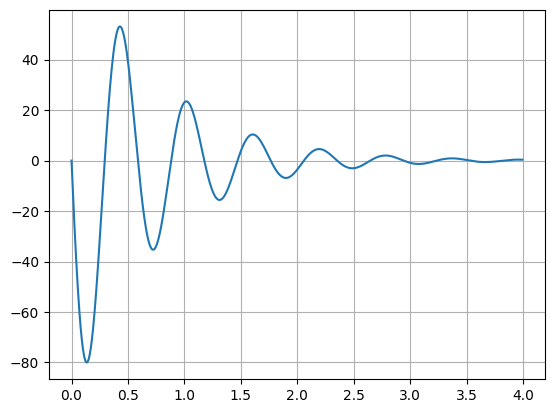

In [ ]:
damped_sine = pd.read_csv(r"results\damped_sine_1700Hz_fit_timeseries.csv")
print(damped_sine)
plt.plot(damped_sine['t_s']*1e3,damped_sine['x_mV'])
plt.grid()
plt.show()

999


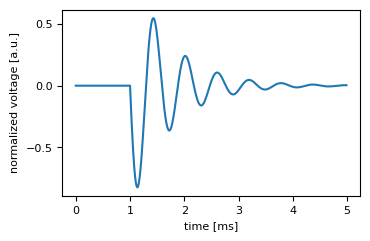

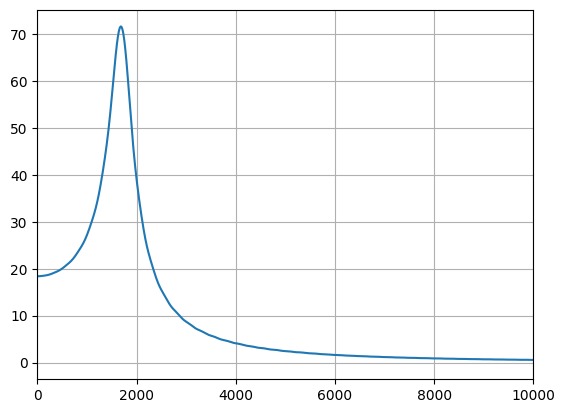

In [ ]:
%matplotlib inline
f   = 1700                   # [Hz]
alpha = 1390.0012397674093   # [1/s]
A_mV  = 1#97.3278421120322     # [mV]
phi   = np.pi                # first wave negative

# Time axis: 0..4 ms at 200 kHz
fs   = 200e3 #Hz                 
tEnd = 5e-3  #s
t = np.arange(0,tEnd-1/fs,1/fs)
print(len(t))

# Signal
stim = (t>1e-3)
x_mV = A_mV * np.exp(-alpha*(t-1e-3)) * np.sin(2*np.pi*f*(t-1e-3) + phi)*stim

plot_damped_sine = 1
if plot_damped_sine:
    plt.plot(t*1e3,x_mV)
    #plt.xlim([1,5.1])
    #plt.ylim([-85,55])

    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)
    plt.xlabel('time [ms]',fontsize = 8)
    plt.ylabel('normalized voltage [a.u.]',fontsize = 8)
    #plt.ylabel('voltage [mV]',fontsize = 8)
    fig = plt.gcf()
    x_size, y_size = fig.get_size_inches()
    fig.set_size_inches(7.6/2,6.7*y_size/(2*x_size))
    fig.tight_layout()
    plt.show()

DTFT = np.fft.rfft(x_mV,n=8192*4)
freq_DTFT = np.fft.rfftfreq(n=8192*4,d=1/(200e3))
mag = np.abs(DTFT)
DTFT_norm = mag/np.max(mag)
# plt.plot(freq_DTFT,DTFT_norm)
# plt.hlines(1/np.sqrt(2),0,20000)

plt.plot(freq_DTFT,mag)
plt.xlim(0,10000)
#plt.xlim(1650,1750)
plt.grid()
plt.show()




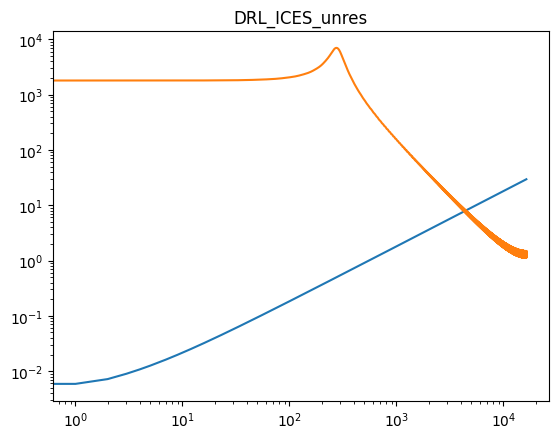

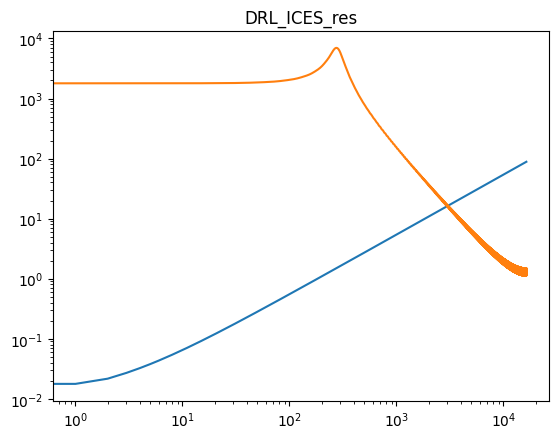

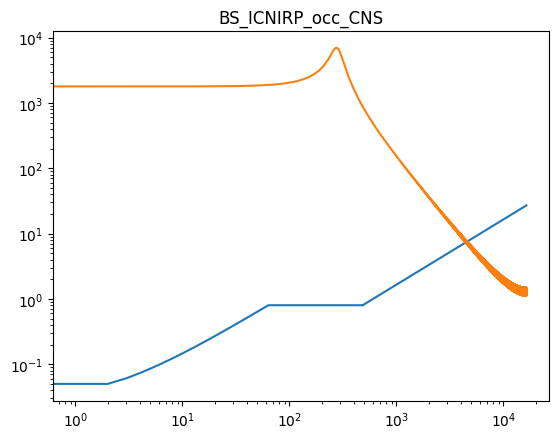

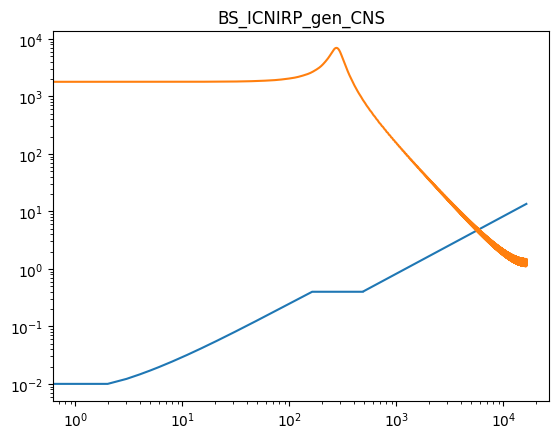

In [ ]:
def give_guidelines(freqs, CNS=0):

    #ICES
    E0_unres = 5.89*1e-3
    E0_res = 1.77*1e-2
    DRL_ICES_unres = [E0_unres if freq < 20 else E0_unres*freq/20 for freq in freqs]
    DRL_ICES_res = [E0_res if freq < 20 else E0_res*freq/20 for freq in freqs]
    #ICNIRP
    BS_ICNIRP_occ_CNS = [0.5/freq if freq < 10 else 0.05 if freq <25 else 2*1e-3*freq if freq < 400 else 0.8 if freq < 3*1e3 else 2.7*1e-4*freq  for freq in freqs]
    #BS_ICNIRP_occ_PNS = np.array([0.8 if freq < 3*1e3 else 2.7*1e-4*freq for freq in freq_array])
    BS_ICNIRP_gen_CNS = [0.1/freq if freq < 10 else 0.01 if freq <25 else 4*1e-4*freq if freq < 1000 else 0.4 if freq < 3*1e3 else 1.35*1e-4*freq  for freq in freqs]
    #BS_ICNIRP_gen_PNS = np.array([0.4 if freq < 3*1e3 else 1.35*1e-4*freq for freq in freq_array])

    if CNS:
        return([DRL_ICES_unres,DRL_ICES_res,BS_ICNIRP_occ_CNS,BS_ICNIRP_gen_CNS])

    return np.max([DRL_ICES_unres,DRL_ICES_res,BS_ICNIRP_occ_CNS,BS_ICNIRP_gen_CNS],axis=0)

DTFT = np.fft.rfft(x_mV,n=8192*4)[1:]
freq_DTFT = np.fft.rfftfreq(n=8192*4,d=1/(200e3))[1:]
mag = np.abs(DTFT)
DTFT_norm = mag/np.max(mag)*100 #E_min_th > 100 V/m

%matplotlib inline
guideline_names = ['DRL_ICES_unres','DRL_ICES_res','BS_ICNIRP_occ_CNS','BS_ICNIRP_gen_CNS']
guidelines = give_guidelines(freq_DTFT,CNS=1)
for ig, guideline in enumerate(guidelines):
    plt.plot(guideline[1:])
    plt.plot(DTFT_norm)
    #plt.xlim(0,2500)
    plt.title(guideline_names[ig])
    plt.yscale('log')
    plt.xscale('log')
    plt.show()
    fraction = DTFT_norm / guideline # do not consider the 0 frequency


In [ ]:
name_martin = r"Exyz\Exyz_EAS\MARTIN_head_E-field.mat"
name_mida = r"Exyz\Exyz_EAS\MIDA_head_E-field.mat"
matf_martin = scipy.io.loadmat(name_martin)
matf_mida = scipy.io.loadmat(name_mida)

In [ ]:
print(matf_mida.keys())
print(f"dx: {np.diff(matf_mida['Axis0'][0,:])[0]*1e3}")
print(f"dy: {np.diff(matf_mida['Axis1'][0,:])[0]*1e3}")
print(f"dz: {np.diff(matf_mida['Axis2'][0,:])[0]*1e3}")
print(f"x0: {matf_mida['Axis0'][0,:][0]*1e3}")
print(f"x-1: {matf_mida['Axis0'][0,:][-1]*1e3}")
print(f"y0: {matf_mida['Axis1'][0,:][0]*1e3}")
print(f"y-1: {matf_mida['Axis1'][0,:][-1]*1e3}")
print(f"z0: {matf_mida['Axis2'][0,:][0]*1e3}")
print(f"z-1: {matf_mida['Axis2'][0,:][-1]*1e3}")
print(matf_mida['Axis0'][0,:].shape)
print(matf_mida['Axis1'][0,:].shape)
print(matf_mida['Axis2'][0,:].shape)
print(matf_mida['Axis0'][0,:].shape[0]*matf_mida['Axis1'][0,:].shape[0]*matf_mida['Axis2'][0,:].shape[0])
sh0, sh1, sh2 = matf_mida['Axis0'][0,:].shape[0] -1, matf_mida['Axis1'][0,:].shape[0] -1, matf_mida['Axis2'][0,:].shape[0] -1
print(matf_mida['Snapshot0'].shape)
E_mida = np.abs(matf_mida['Snapshot0'].reshape(sh2,sh1,sh0,3))
E_mag_mida_orig = np.sqrt(E_mida[:,:,:,0]**2+E_mida[:,:,:,1]**2+E_mida[:,:,:,2]**2)
print(sh0,sh1,sh2)
print(E_mag_mida_orig.shape)
E_mag_mida_tr = np.transpose(E_mag_mida_orig, (1, 2, 0))
E_mag_mida = np.flip(E_mag_mida_tr, axis=1)
sh0,sh1,sh2 = E_mag_mida.shape
print(sh0,sh1,sh2)


plt.imshow(E_mag_mida[sh0//2,:,:],extent=[0,sh2*0.5,0,sh1*0.5], interpolation='nearest')
cbar = plt.colorbar()
plt.xticks([50*i for i in range(5)],fontsize=8)
plt.yticks([50*i for i in range(5)],fontsize=8)
plt.xlabel('inferior-superior [mm]',fontsize = 8)
plt.ylabel('anterior-posterior [mm]',fontsize = 8)
cbar.ax.set_yticks([0.05*i for i in range(8)])
cbar.ax.tick_params(labelsize=8)
cbar.set_label('|E| [V/m]',fontsize=8)
#cbar.ax.yaxis.set_label_coords(10, 0.5)
fig = plt.gcf()
x_size, y_size = fig.get_size_inches()
fig.set_size_inches(7.42/3,7.42*y_size/(3*x_size))
fig.tight_layout()
plt.show()

plt.imshow(E_mag_mida[:,sh1//2,:],extent=[0,sh2*0.5,0,sh0*0.5], interpolation='nearest') #
cbar = plt.colorbar()
plt.xticks([50*i for i in range(5)],fontsize=8)
plt.yticks([50*i for i in range(4)],fontsize=8)
plt.xlabel('inferior-superior [mm]',fontsize = 8)
plt.ylabel('right-left [mm]',fontsize = 8)
cbar.ax.set_yticks([0.25*i for i in range(9)])
cbar.ax.tick_params(labelsize=8)
cbar.set_label('|E| [V/m]',fontsize=8)
#cbar.ax.yaxis.set_label_coords(10, 0.5)
fig = plt.gcf()
x_size, y_size = fig.get_size_inches()
fig.set_size_inches(7.42/3,7.42*y_size/(3*x_size))
fig.tight_layout()
plt.show()

plt.imshow(E_mag_mida[:,:,sh2//2],extent=[0,sh1*0.5,0,sh0*0.5], interpolation='nearest') #
cbar = plt.colorbar()
plt.xticks([50*i for i in range(5)],fontsize=8)
plt.yticks([50*i for i in range(4)],fontsize=8)
plt.xlabel('posterior-anterior [mm]',fontsize = 8)
plt.ylabel('right-left [mm]',fontsize = 8)
cbar.ax.tick_params(labelsize=8)
cbar.set_label('|E| [V/m]',fontsize=8)
#cbar.ax.yaxis.set_label_coords(10, 0.5)
cbar.ax.set_yticks([0.2*i for i in range(9)])
fig = plt.gcf()
x_size, y_size = fig.get_size_inches()
fig.set_size_inches(7.42/3,7.42*y_size/(3*x_size))
fig.tight_layout()
plt.show()

E_max_mida = np.max(np.nan_to_num(E_mag_mida))
E_99_mida = np.percentile(np.nan_to_num(E_mag_mida),99)
print(f'E_max_mida: {E_max_mida}',f'E_99_mida: {E_99_mida}')

dict_keys(['__header__', '__version__', '__globals__', 'Snapshot0', 'Axis0', 'Axis1', 'Axis2'])
dx: 0.4991127400902906
dy: 0.4989318847656299
dz: 0.4989849303413951
x0: 923.6371459960939
x-1: 1140.2520751953125
y0: 174.95098876953125
y-1: 337.60278320312506
z0: 1075.6881103515625
z-1: 1308.2150878906252
(435,)
(327,)
(467,)
66428415
(65931544, 3)
434 326 466
(466, 326, 434)
326 434 466
E_max_mida: 2.802028179168701 E_99_mida: 0.19133960962295538


In [ ]:
print(matf_martin.keys())
print(f"dx: {np.diff(matf_martin['Axis0'][0,:])[0]*1e3}")
print(f"dy: {np.diff(matf_martin['Axis1'][0,:])[0]*1e3}")
print(f"dz: {np.diff(matf_martin['Axis2'][0,:])[0]*1e3}")
print(f"x0: {matf_martin['Axis0'][0,:][0]*1e3}")
print(f"x-1: {matf_martin['Axis0'][0,:][-1]*1e3}")
print(f"y0: {matf_martin['Axis1'][0,:][0]*1e3}")
print(f"y-1: {matf_martin['Axis1'][0,:][-1]*1e3}")
print(f"z0: {matf_martin['Axis2'][0,:][0]*1e3}")
print(f"z-1: {matf_martin['Axis2'][0,:][-1]*1e3}")
print(matf_martin['Axis0'][0,:].shape)
print(matf_martin['Axis1'][0,:].shape)
print(matf_martin['Axis2'][0,:].shape)
print(matf_martin['Axis0'][0,:].shape[0]*matf_martin['Axis1'][0,:].shape[0]*matf_martin['Axis2'][0,:].shape[0])
sh0, sh1, sh2 = matf_martin['Axis0'][0,:].shape[0] -1, matf_martin['Axis1'][0,:].shape[0] -1, matf_martin['Axis2'][0,:].shape[0] -1
print(matf_martin['Snapshot0'].shape)
E_martin = np.abs(matf_martin['Snapshot0'].reshape(sh2,sh1,sh0,3))
E_mag_martin_orig = np.sqrt(E_martin[:,:,:,0]**2+E_martin[:,:,:,1]**2+E_martin[:,:,:,2]**2)
print(sh0,sh1,sh2)
print(E_mag_martin_orig.shape)
E_mag_martin_tr = np.transpose(E_mag_martin_orig, (1, 2, 0))
E_mag_martin = np.flip(E_mag_martin_tr, axis=1)
sh0,sh1,sh2 = E_mag_martin.shape
print(sh0,sh1,sh2)

plt.imshow(E_mag_martin[sh0//2,:,:],extent=[0,sh2*0.5,0,sh1*0.5], interpolation='nearest')
cbar = plt.colorbar()
plt.xticks([50*i for i in range(5)],fontsize=8)
plt.yticks([50*i for i in range(5)],fontsize=8)
plt.xlabel('inferior-superior [mm]',fontsize = 8)
plt.ylabel('anterior-posterior [mm]',fontsize = 8)
cbar.ax.set_yticks([0.1*i for i in range(6)])
cbar.ax.tick_params(labelsize=8)
cbar.set_label('|E| [V/m]',fontsize=8)
#cbar.ax.yaxis.set_label_coords(10, 0.5)
fig = plt.gcf()
x_size, y_size = fig.get_size_inches()
fig.set_size_inches(7.48/3,7.48*y_size/(3*x_size))
fig.tight_layout()
plt.show()


plt.imshow(E_mag_martin[:,sh1//2,:],extent=[0,sh2*0.5,0,sh0*0.5], interpolation='nearest') #
cbar = plt.colorbar()
plt.xticks([50*i for i in range(4)],fontsize=8)
plt.yticks([50*i for i in range(4)],fontsize=8)
plt.xlabel('inferior-superior [mm]',fontsize = 8)
plt.ylabel('right-left [mm]',fontsize = 8)
cbar.ax.set_yticks([0.1*i for i in range(8)])
cbar.ax.tick_params(labelsize=8)
cbar.set_label('|E| [V/m]',fontsize=8)
#cbar.ax.yaxis.set_label_coords(10, 0.5)
fig = plt.gcf()
x_size, y_size = fig.get_size_inches()
fig.set_size_inches(7.48/3,7.48*y_size/(3*x_size))
fig.tight_layout()
plt.show()

plt.imshow(E_mag_martin[:,:,sh2//2],extent=[0,sh1*0.5,0,sh0*0.5], interpolation='nearest') #
cbar = plt.colorbar()
plt.xticks([50*i for i in range(4)],fontsize=8)
plt.yticks([50*i for i in range(4)],fontsize=8)
plt.xlabel('posterior-anterior [mm]',fontsize = 8)
plt.ylabel('right-left [mm]',fontsize = 8)
cbar.ax.set_yticks([0.2*i for i in range(6)])
cbar.ax.tick_params(labelsize=8)
cbar.set_label('|E| [V/m]',fontsize=8)
#cbar.ax.yaxis.set_label_coords(10, 0.5)
fig = plt.gcf()
x_size, y_size = fig.get_size_inches()
fig.set_size_inches(7.48/3,7.48*y_size/(3*x_size))
fig.tight_layout()
plt.show()

E_max_martin = np.max(np.nan_to_num(E_mag_martin))
E_99_martin = np.percentile(np.nan_to_num(E_mag_martin),99)
print(f'E_max_martin: {E_max_martin}',f'E_99_martin: {E_99_martin}')

dict_keys(['__header__', '__version__', '__globals__', 'Snapshot0', 'Axis0', 'Axis1', 'Axis2'])
dx: 1.1273728073988298
dy: 0.49849725860398597
dz: 0.500000000000167
x0: 919.7791137695312
x-1: 1117.14794921875
y0: 184.81924438476562
y-1: 337.3594055175781
z0: 1031.766357421875
z-1: 1230.2486572265625
(392,)
(307,)
(394,)
47415536
(47020878, 3)
391 306 393
(393, 306, 391)
306 391 393
E_max_martin: 2.8280835151672363 E_99_martin: 0.21324220299720764


131863088
115
(466, 326, 434, 2)
115
(326, 434, 466)
uint8


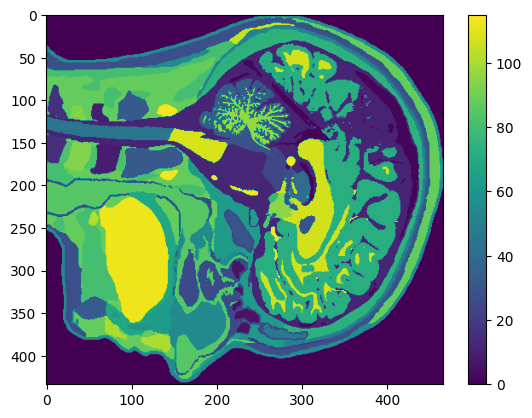

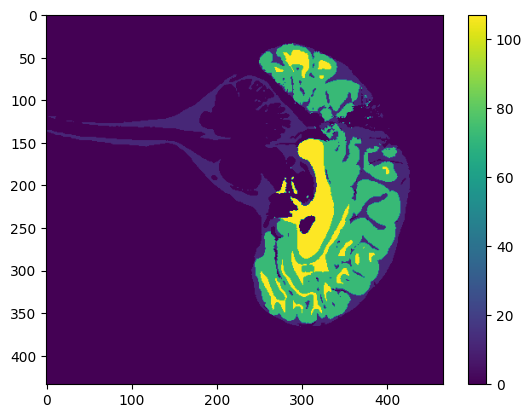

In [ ]:
dims = (466, 326, 434,2)  
dtype = np.uint8  

path = r"Exyz\Exyz_EAS\MIDA_head_voxels.raw"

# read the binary data
data = np.fromfile(path, dtype=dtype)

print(len(data))
print(np.max(data))

# reshape into 3D volume
brainmap_orig = data.reshape(dims)
print(brainmap_orig.shape)
brainmap_0 = brainmap_orig[:,:,:,0]
brainmap_tr = np.transpose(brainmap_0, (1, 2, 0))
brainmap_MIDA = np.flip(brainmap_tr, axis=1)

# for i in range(np.max(brainmap_MIDA)):
#     print(i)
#     plt.imshow(((brainmap_MIDA==i)*1)[brainmap_MIDA.shape[0]//2,:,:])
#     plt.show()
print(np.max(brainmap_MIDA))

plt.imshow(brainmap_MIDA[brainmap_MIDA.shape[0]//2,:,:])
plt.colorbar()
print(brainmap_MIDA.shape)
print(brainmap_MIDA.dtype)
plt.show()

brainmap_slice = brainmap_MIDA[brainmap_MIDA.shape[0]//2,:,:]
plt.imshow((brainmap_slice==72)*72+(brainmap_slice==107)*107+(brainmap_slice==12)*12)
plt.colorbar()
plt.show()


94041756
85
(393, 306, 391, 2)
85


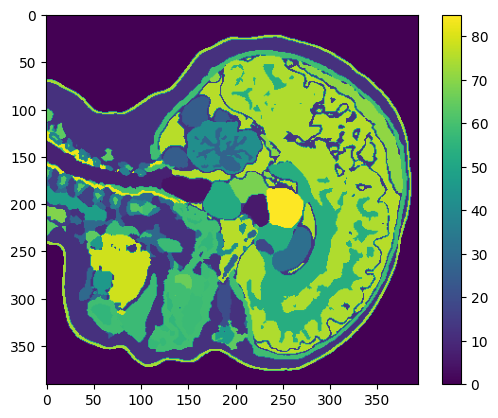

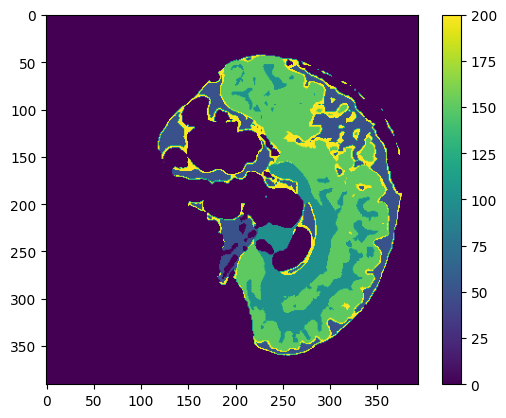

In [ ]:
dims = (393, 306, 391, 2)
dtype = np.uint8  

path = r"Exyz\Exyz_EAS\MARTIN_head_voxels.raw"

# read the binary data
data = np.fromfile(path, dtype=dtype)

print(len(data))
print(np.max(data))

# reshape into 3D volume
brainmap_orig = data.reshape(dims)
print(brainmap_orig.shape)
brainmap_0 = brainmap_orig[:,:,:,0]
brainmap_tr = np.transpose(brainmap_0, (1, 2, 0))
brainmap_MARTIN = np.flip(brainmap_tr, axis=1)

# for i in range(np.max(brainmap_MARTIN)):
#     print(i)
#     plt.imshow(((brainmap_MARTIN==i)*1)[brainmap_MARTIN.shape[0]//2,:,:])
#     plt.show()

print(np.max(brainmap_MARTIN))

plt.imshow(brainmap_MARTIN[brainmap_MARTIN.shape[0]//2,:,:])
plt.colorbar()
plt.show()

brainmap_slice = brainmap_MARTIN[brainmap_MARTIN.shape[0]//2,:,:]
plt.imshow((brainmap_slice==75)*150+(brainmap_slice==53)*100+(brainmap_slice==76)*50+(brainmap_slice==13)*200)
plt.colorbar()
plt.show()

In [92]:
from skimage import measure
import meshio

def make_boundary_mesh(name,matrix):
    "make a mesh of the surface boundary between two tissues (in the end I used all tissues of csf and all tissues of wm instead of just 1)"
    "changed it to specifically GM/CSF border and GM/WM border"

    #matrix = brainmap
    # Assume `matrix` is your 3D numpy array
    mask_GM = (matrix == 75) #MARTIN: 75 #MIDA: 72
    mask_WM = (matrix == 53) #MARTIN: 53 #MIDA: 107
    mask_CSF = (matrix == 76) + (matrix == 13) #MARTIN: 76 + meninges: 13 #MIDA: 12
    # Find boundary: voxels adjacent to both masks
    boundaryGW = np.zeros_like(matrix, dtype=bool)
    boundaryGC = np.zeros_like(matrix, dtype=bool)
    # Dilate mask16 and intersect with mask34
    from scipy.ndimage import binary_dilation

    boundaryGW = binary_dilation(mask_GM) & mask_WM
    boundaryGC = binary_dilation(mask_GM) & mask_CSF
    print(np.sum(boundaryGW))
    #boundaryWC = binary_dilation(mask_WM) & mask_CSF #should be (almost) empty

    # Extract mesh using marching cubes
    vertsGW, facesGW, normalsGW, valuesGW = measure.marching_cubes(boundaryGW.astype(float), level=0.5)
    vertsGC, facesGC, normalsGC, valuesGC = measure.marching_cubes(boundaryGC.astype(float), level=0.5)
    #vertsWC, facesWC, normalsWC, valuesWC = measure.marching_cubes(boundaryWC.astype(float), level=0.5)

    meshio.write(rf"tissue_meshes\EAS\{name}\boundary_gm_wm.stl", meshio.Mesh(points=vertsGW, cells=[("triangle", facesGW)]))
    meshio.write(rf"tissue_meshes\EAS\{name}\boundary_gm_csf.stl", meshio.Mesh(points=vertsGC, cells=[("triangle", facesGC)]))
#make_boundary_mesh('MIDA',brainmap_MIDA)
make_boundary_mesh('MARTIN',brainmap_MARTIN)

425087


In [ ]:
import trimesh
import open3d as o3d
from scipy.spatial import cKDTree

def create_layers(subject):

    # Input STL files
    file1 = rf"tissue_meshes\EAS\{subject}\boundary_gm_csf.stl"  # Replace with your first STL file
    file2 = rf"tissue_meshes\EAS\{subject}\boundary_gm_wm.stl"  # Replace with your second STL file
    
    # Normalized depths for intermediate layers
    depths = [0.06, 0.4, 0.55, 0.65, 0.85]

    # Load meshes using trimesh
    mesh1 = trimesh.load_mesh(file1)
    mesh2 = trimesh.load_mesh(file2)
    print('loaded')
    # Convert trimesh meshes to Open3D point clouds for ICP
    pcd1 = o3d.geometry.PointCloud()
    pcd1.points = o3d.utility.Vector3dVector(mesh1.vertices)

    pcd2 = o3d.geometry.PointCloud()
    pcd2.points = o3d.utility.Vector3dVector(mesh2.vertices)

    # Initial alignment (identity)
    trans_init = np.eye(4)

    # ICP registration
    threshold = 5.0  # Adjust based on scale of your meshes
    reg_p2p = o3d.pipelines.registration.registration_icp(
        pcd2, pcd1, threshold, trans_init,
        o3d.pipelines.registration.TransformationEstimationPointToPoint()
    )

    # Apply ICP transformation to mesh2
    mesh2.apply_transform(reg_p2p.transformation)

    # Extract aligned vertices
    vertices1 = mesh1.vertices
    vertices2 = mesh2.vertices
    faces1 = mesh1.faces  # We'll reuse faces from mesh1 for output layers

    # Build KDTree for mesh2 to find nearest points for mesh1 vertices
    tree2 = cKDTree(vertices2)
    _, idx = tree2.query(vertices1)
    matched_vertices2 = vertices2[idx]

    # Interpolation function
    def interpolate_vertices(v1, v2, depth):
        return (1 - depth) * v1 + depth * v2

    # Generate and save intermediate layers
    layers = ['1','23','4','5','6']
    for i, d in enumerate(depths):
        print(i)
        interpolated_vertices = interpolate_vertices(vertices1, matched_vertices2, d)
        new_mesh = trimesh.Trimesh(vertices=interpolated_vertices, faces=faces1)
        output_file = f"tissue_meshes\\EAS\\{subject}\\layers\\layer_{layers[i]}_depth_{d:.2f}.stl"
        new_mesh.export(output_file)
        print(layers[i])
        print(f"Saved interpolated layer {i} at depth {d} -> {output_file}")

for subject in ['MIDA','MARTIN']:
    print(subject)
    create_layers(subject)


MIDA
loaded
0
1
Saved interpolated layer 0 at depth 0.06 -> tissue_meshes\EAS\MIDA\layers\layer_1_depth_0.06.stl
1
23
Saved interpolated layer 1 at depth 0.4 -> tissue_meshes\EAS\MIDA\layers\layer_23_depth_0.40.stl
2
4
Saved interpolated layer 2 at depth 0.55 -> tissue_meshes\EAS\MIDA\layers\layer_4_depth_0.55.stl
3
5
Saved interpolated layer 3 at depth 0.65 -> tissue_meshes\EAS\MIDA\layers\layer_5_depth_0.65.stl
4
6
Saved interpolated layer 4 at depth 0.85 -> tissue_meshes\EAS\MIDA\layers\layer_6_depth_0.85.stl
MARTIN
loaded
0
1
Saved interpolated layer 0 at depth 0.06 -> tissue_meshes\EAS\MARTIN\layers\layer_1_depth_0.06.stl
1
23
Saved interpolated layer 1 at depth 0.4 -> tissue_meshes\EAS\MARTIN\layers\layer_23_depth_0.40.stl
2
4
Saved interpolated layer 2 at depth 0.55 -> tissue_meshes\EAS\MARTIN\layers\layer_4_depth_0.55.stl
3
5
Saved interpolated layer 3 at depth 0.65 -> tissue_meshes\EAS\MARTIN\layers\layer_5_depth_0.65.stl
4
6
Saved interpolated layer 4 at depth 0.85 -> tissue_

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


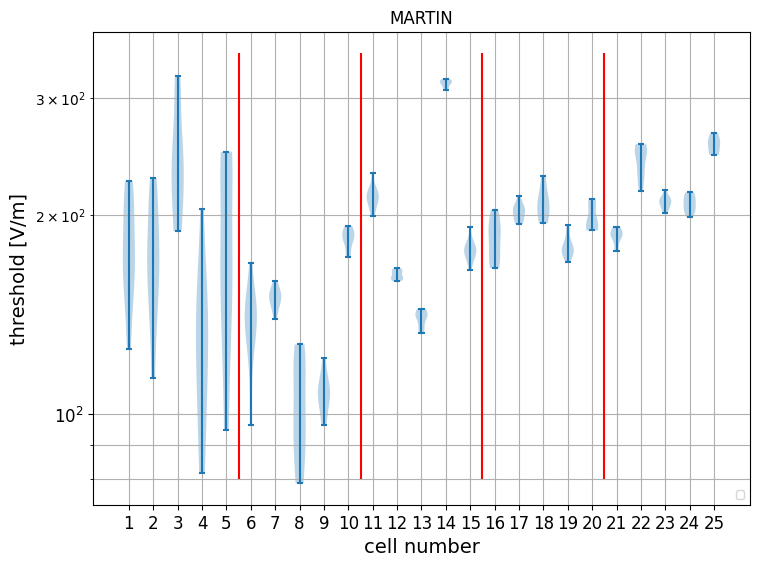

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


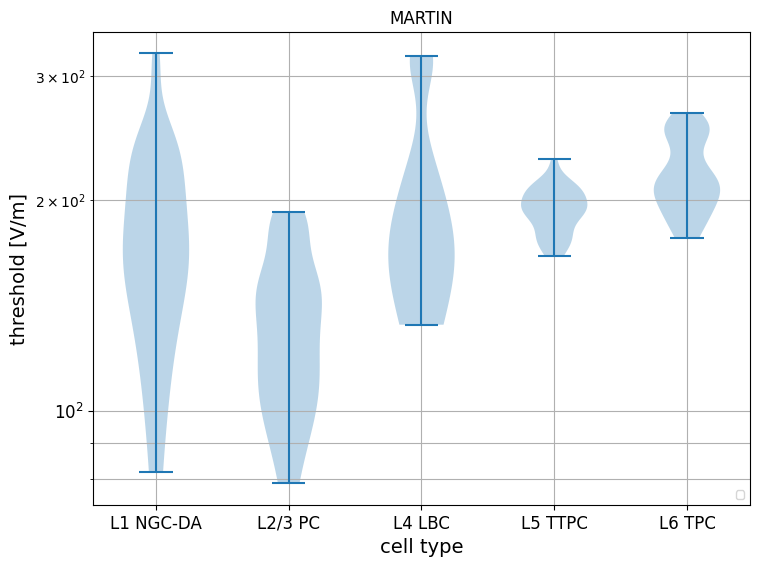

In [ ]:
%matplotlib inline
"""cell variations"""

subject = 'MARTIN'

len_loc = 10
len_celltypes = 5
len_cellclones = 5
cells = [5*celltype + cellclone + 1 for celltype in range(len_celltypes) for cellclone in range(len_cellclones)]

colors = ['b','g','r','c','m','y','tab:orange','tab:pink','tab:brown','k']
colors = ['b','y','r','g','c']
type1, type2, type3, type4, type5 = "L1 NGC-DA", "L2/3 PC", "L4 LBC", "L5 TTPC", "L6 TPC"
celltypes = [type1, type2, type3, type4, type5]
cell_names = [type1]*5 + [type2]*5 + [type3]*5 + [type4]*5 + [type5]*5
i = 0

violins = []
violin_cells = []

for ict,celltype in enumerate(range(len_celltypes)):
    threshs_cells = np.empty(50)
    for icc,cellclone in enumerate(range(len_cellclones)):
        with open(rf"results\damped\EAS_{subject}_interpol_linear_logspace_(10, 2, 5)_cell_nr_{5*celltype+cellclone+1}_dt_fact_100.pkl",'rb') as fEAS:
            EAS = pickle.load(fEAS)
        threshs_locs = np.empty(10)
        for i_loc in range(10):
            threshs_locs[i_loc] = EAS['hotspot'][i_loc]['thresh']#/np.sqrt(2) #peak->RMS
        violins += [threshs_locs]
        threshs_cells[icc*10:(icc+1)*10] = threshs_locs
    violin_cells += [threshs_cells]
    
plt.violinplot(violins)
for vref in [5.5,10.5,15.5,20.5]:
    #plt.vlines(vref,10,100,color='r')
    plt.vlines(vref,80,350,color='r')

#plot_guidelines()
plt.grid(which='both')
plt.xlabel('cell number',fontsize = 14)
plt.ylabel('threshold [V/m]',fontsize = 14)
plt.xticks([i for i in range(1,26)],fontsize = 12)
plt.yticks(fontsize = 12)
#plt.xscale('log')
plt.yscale('log')
plt.legend(loc='lower right',fontsize=8)
#plt.title(f'cells: {cells}, subjects: {subjects}, directions: {directions} exposure, 10 closest locations',fontsize=8)
plt.title(subject)
plt.tight_layout()

fig = plt.gcf()
x_size, y_size = fig.get_size_inches()
fig.set_size_inches(7.7,7.7*y_size/(x_size))
fig.tight_layout()
plt.show()

plt.violinplot(violin_cells)

#plot_guidelines()
plt.grid(which='both')
plt.xlabel('cell type',fontsize = 14)
plt.ylabel('threshold [V/m]',fontsize = 14)
plt.xticks([i for i in range(1,6)],celltypes,fontsize = 12)
plt.yticks(fontsize = 12)
#plt.xscale('log')
plt.yscale('log')
plt.legend(loc='lower right',fontsize=8)
#plt.title(f'cells: {cells}, subjects: {subjects}, directions: {directions} exposure, 10 closest locations',fontsize=8)
plt.title(subject)
plt.tight_layout()

fig = plt.gcf()
x_size, y_size = fig.get_size_inches()
fig.set_size_inches(7.7,7.7*y_size/(x_size))
fig.tight_layout()
plt.show()


damped
MARTIN [115.60590425695321, 111.40966616692089, 187.53816349009935, 234.98023057306776, 249.3075163728744]
inverse damped
MARTIN [123.6797940310501, 90.87449668511415, 171.84550737900236, 158.88359189048606, 263.8896712974552]
damped
MIDA [130.33458016908747, 113.98584880508258, 136.91754901987215, 136.8355182553764, 209.26868330513201]
inverse damped
MIDA [126.01155888016093, 97.89961588746415, 116.7092701863418, 124.05102360871228, 152.66745580305798]


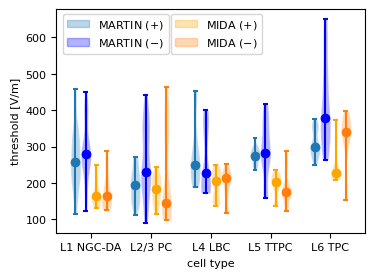

In [ ]:
%matplotlib inline
'MARTIN vs MIDA'

import matplotlib.patches as mpatches
import matplotlib

damped = 1
inv_damped = 1

labels = []
def add_label(violin, label):
    color = violin["bodies"][0].get_facecolor().flatten()
    labels.append((mpatches.Patch(color=color), label))


def color_violin(violin, color):
    for pc in violin['bodies']:
        pc.set_facecolor(color)
        pc.set_edgecolor('white')
        #pc.set_alpha(0.7)

    for k in ['cmins', 'cmaxes', 'cbars', 'cmedians']:
        if k in parts:
            violin[k].set_color(color)


for subject in ['MARTIN','MIDA']:


    len_loc = 10
    len_celltypes = 5
    len_cellclones = 5
    cells = [5*celltype + cellclone + 1 for celltype in range(len_celltypes) for cellclone in range(len_cellclones)]

    colors = ['b','g','r','c','m','y','tab:orange','tab:pink','tab:brown','k']
    colors = ['b','y','r','g','c']
    type1, type2, type3, type4, type5 = "L1 NGC-DA", "L2/3 PC", "L4 LBC", "L5 TTPC", "L6 TPC"
    celltypes = [type1, type2, type3, type4, type5]
    cell_names = [type1]*5 + [type2]*5 + [type3]*5 + [type4]*5 + [type5]*5
    i = 0

    violins = []
    violin_cells = []

    loc_mid = (np.arange(1,6))*2*1.5
    loc_leftleft = loc_mid - 0.13*3*2
    loc_left = loc_mid - 0.13*2
    
    loc_right = loc_mid + 0.13*2
    loc_rightright = loc_mid + 0.13*3*2

    if damped:
        print('damped')
        for ict,celltype in enumerate(range(len_celltypes)):
            threshs_cells = np.empty(50)
            for icc,cellclone in enumerate(range(len_cellclones)):
                with open(rf"results\damped\EAS_{subject}_interpol_linear_logspace_(10, 2, 5)_cell_nr_{5*celltype+cellclone+1}_dt_fact_100.pkl",'rb') as fEAS:
                    EAS = pickle.load(fEAS)
                threshs_locs = np.empty(10)
                for i_loc in range(10):
                    threshs_locs[i_loc] = EAS['hotspot'][i_loc]['thresh']#/np.sqrt(2) #peak->RMS
                violins += [threshs_locs]
                threshs_cells[icc*10:(icc+1)*10] = threshs_locs
            violin_cells += [threshs_cells]
        if subject == 'MIDA':
            color = 'orange'
            parts = plt.violinplot(violin_cells, positions=loc_right)
            color_violin(parts,color)
            add_label(parts,subject+' ($+$)')
            plt.scatter(loc_right,[np.median(e) for e in violin_cells],c=color)
            print(subject,[np.min(e) for e in violin_cells])
        else:
            color = 'tab:blue'
            parts = plt.violinplot(violin_cells, positions=loc_leftleft)
            color_violin(parts,color)
            add_label(parts,subject+' ($+$)')
            plt.scatter(loc_leftleft,[np.median(e) for e in violin_cells],c=color)
            print(subject,[np.min(e) for e in violin_cells])

    violins = []
    violin_cells = []

    if inv_damped:
        print('inverse damped')
        for ict,celltype in enumerate(range(len_celltypes)):
            threshs_cells = np.empty(50)
            for icc,cellclone in enumerate(range(len_cellclones)):
                with open(rf"results\invdamped\EAS_{subject}_interpol_linear_logspace_(10, 2, 5)_cell_nr_{5*celltype+cellclone+1}_dt_fact_100.pkl",'rb') as fEAS:
                    EAS = pickle.load(fEAS)
                threshs_locs = np.empty(10)
                for i_loc in range(10):
                    threshs_locs[i_loc] = -EAS['hotspot'][i_loc]['thresh']#/np.sqrt(2) #peak->RMS
                violins += [threshs_locs]
                threshs_cells[icc*10:(icc+1)*10] = threshs_locs
            violin_cells += [threshs_cells]
        if subject == 'MIDA':
            color = 'tab:orange'
            parts = plt.violinplot(violin_cells, positions=loc_rightright)
            color_violin(parts,color)
            add_label(parts,subject +' ($-$)')
            plt.scatter(loc_rightright,[np.median(e) for e in violin_cells],c=color)
            print(subject,[np.min(e) for e in violin_cells])
        else:
            color = 'blue'
            parts = plt.violinplot(violin_cells, positions=loc_left)
            color_violin(parts,color)
            add_label(parts,subject +' ($-$)')
            plt.scatter(loc_left,[np.median(e) for e in violin_cells],c=color)
            print(subject,[np.min(e) for e in violin_cells])

#plot_guidelines()
#plt.grid(which='both')
#plt.xscale('log')
plt.xlabel('cell type',fontsize = 8)
plt.ylabel('threshold [V/m]',fontsize = 8)
plt.xticks(loc_mid,celltypes,fontsize = 8)
plt.yticks(fontsize = 8)
#plt.yscale('log')
# plt.legend(*zip(*labels[:2]), loc='upper left',fontsize=8)
# plt.legend(*zip(*labels[2:]), loc='upper center',fontsize=8)
#plt.title(f'cells: {cells}, subjects: {subjects}, directions: {directions} exposure, 10 closest locations',fontsize=8)
plt.tight_layout()

fig = plt.gcf()
ax = fig.get_axes()

handles1, labels1 = zip(*labels[:2])
leg1 = ax[0].legend(handles1, labels1, loc=(0.02,0.8), fontsize=8)
ax[0].add_artist(leg1)
handles2, labels2 = zip(*labels[2:])
ax[0].legend(handles2, labels2, loc=(0.37,0.8), fontsize=8)

#ax[0].set_yscale('log')
#ax[0].set_yticks([100,200,300])
#ax[0].tick_params(axis='both', which='both', labelsize=8, size=8)
ax[0].get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
x_size, y_size = fig.get_size_inches()
fig.set_size_inches(7.7/2,7.7*y_size/(2*x_size))
fig.tight_layout()
plt.show()
